In [1]:
# Import necessary packages
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
# Read data, here mutation data from DepMap and lists of specific v pleiotropic proteins
dep = pd.read_csv('OmicsSomaticMutations.csv')
df_one= pd.read_csv('proteins_assoc_onetrnonly.csv')
df_many= pd.read_csv('proteins_assoc_420trn.csv')

/tmp/kritis/46897236/c0300ood18.ll.unc.edu/ipykernel_2863836/158126986.py:2: DtypeWarning: Columns (20,48,52,54,55,56,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  dep = pd.read_csv('OmicsSomaticMutations.csv')


In [3]:
# Clean up depmap mutation df
dep = dep[['HugoSymbol','ProteinChange','ModelID']].copy()
dep = dep.dropna()
dep['position'] = dep['ProteinChange'].str.extract('(\\d+)')
dep['position'] = dep['position'].astype(int)

In [4]:
# If you run the STARMAP pipeline on all 15k proteins, you can use this step to append the clust 
# (RFI) IDs to the protein list
# Instructions for how to do this are under pipeline

# res_list = []

# for i in range(len(df_one)):
#     gene = df_one["protein"][i]
#     sub = dep[dep["HugoSymbol"] == gene].drop_duplicates("position").reset_index(drop=True)

#     nmf_path = f"../NMF_redo/output/{gene[0]}/{gene}_nmfinfo_final.csv"
#     if os.path.exists(nmf_path):
#         nmf = pd.read_csv(nmf_path)
#         sub = sub.merge(
#             nmf[["res", "clust"]],
#             left_on="position",
#             right_on="res",
#             how="left"
#         ).drop(columns=["position"])

#         if sub["clust"].notna().any():
#             mode_clust = sub["clust"].value_counts().idxmax()
#             sub_filtered = sub[sub["clust"] == mode_clust]
#         else:
#             sub_filtered = sub.iloc[0:0]

#         # explicitly handle empty result
#         if sub_filtered.empty:
#             res_list.append(0)      # or np.nan, depending on semantics
#         else:
#             res_list.append(len(sub_filtered))

#     else:
#         res_list.append(np.nan)

# df_one['clust_res'] = res_list
# df_one = df_one[df_one['clust_res']>0]
# df_one = df_one.sort_values('clust_res',ascending=False)
# df_one.to_csv('proteins_assoc_onetrnonly_mutations_clust.csv',index=False)

In [5]:
# For the plot, we will pick up after this step with the output
df_one_clust = pd.read_csv('proteins_assoc_onetrnonly_mutations_clust.csv')

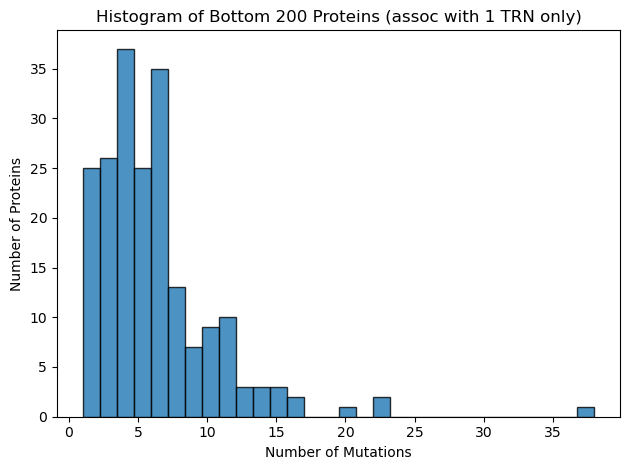

In [6]:
# Plot as histogram 
plt.hist(
    df_one_clust["clust_res"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

plt.grid(False)                # turn off grid
plt.xlabel("Number of Mutations")
plt.ylabel("Number of Proteins")
plt.title("Histogram of Bottom 200 Proteins (assoc with 1 TRN only)")
plt.tight_layout()
plt.show()

In [7]:
# If you run the STARMAP pipeline on all 15k proteins, you can use this step to append the clust 
# (RFI) IDs to the protein list
# Instructions for how to do this are under pipeline

# for i in range(len(df_many)):
#     gene = df["protein"][i]
#     sub = dep[dep["HugoSymbol"] == gene].drop_duplicates("position").reset_index(drop=True)

#     nmf_path = f"../NMF_redo/output/{gene[0]}/{gene}_nmfinfo_final.csv"
#     if os.path.exists(nmf_path):
#         nmf = pd.read_csv(nmf_path)
#         sub = sub.merge(
#             nmf[["res", "clust"]],
#             left_on="position",
#             right_on="res",
#             how="left"
#         ).drop(columns=["position"])

#         if sub["clust"].notna().any():
#             mode_clust = sub["clust"].value_counts().idxmax()
#             sub_filtered = sub[sub["clust"] == mode_clust]
#         else:
#             sub_filtered = sub.iloc[0:0]

#         # explicitly handle empty result
#         if sub_filtered.empty:
#             res_list.append(0)      # or np.nan, depending on semantics
#         else:
#             res_list.append(len(sub_filtered))

#     else:
#         res_list.append(np.nan)

# df_many['num_mut'] = res_list
# df_many['num_clust'] = clust_list
# df_many = df_many[df['num_mut']>0]
# df_many = df_many.sort_values('num_mut',ascending=False)
# df_many.to_csv('proteins_assoc_420trn_mutations_clust.csv',index=False)

In [8]:
# For the plot, we will pick up after this step with the output
df_many_clust = pd.read_csv('proteins_assoc_420trn_mutations_clust.csv')

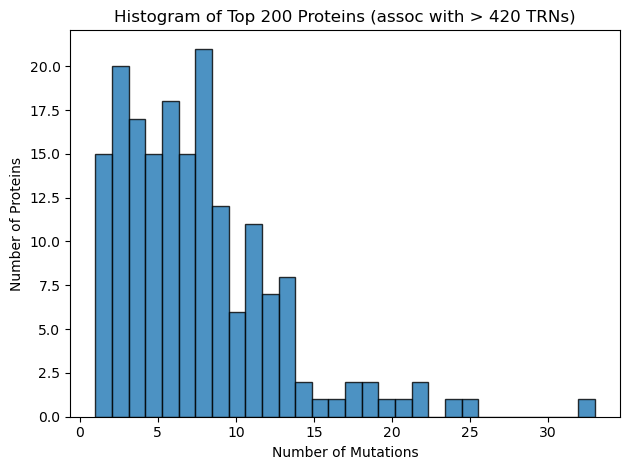

In [9]:
# Plot as histogram 
plt.hist(
    df_many_clust["clust_res"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

plt.grid(False)                # turn off grid
plt.xlabel("Number of Mutations")
plt.ylabel("Number of Proteins")
plt.title("Histogram of Top 200 Proteins (assoc with > 420 TRNs)")
plt.tight_layout()
plt.show()

In [10]:
#Chi2 test between two categorical distributions

# frequency table
counts = pd.crosstab(
    pd.concat([df_one_clust['clust_res'], df_many_clust['clust_res']], keys=['df_one_clust','df_many_clust']),
    columns='count'
).unstack(fill_value=0)

# simpler:
freq = pd.concat([
    df_one_clust['clust_res'].value_counts(),
    df_many_clust['clust_res'].value_counts()
], axis=1).fillna(0)

chi2, pval, _, _ = chi2_contingency(freq)

print(pval)

0.10300757771223935
